<a href="https://colab.research.google.com/github/SOURAV143-BIT/INTRO-TO-NN-FRAMEWORKS/blob/main/INTRO_TO_NN_FRAMEWORKS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Handwritten Digit Classification using ANN
# MNIST Dataset




In [2]:

# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD


In [3]:
# Load MNIST Dataset

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)
print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images : (60000, 28, 28)
Testing Images  : (10000, 28, 28)
Training Labels : (60000,)
Testing Labels  : (10000,)


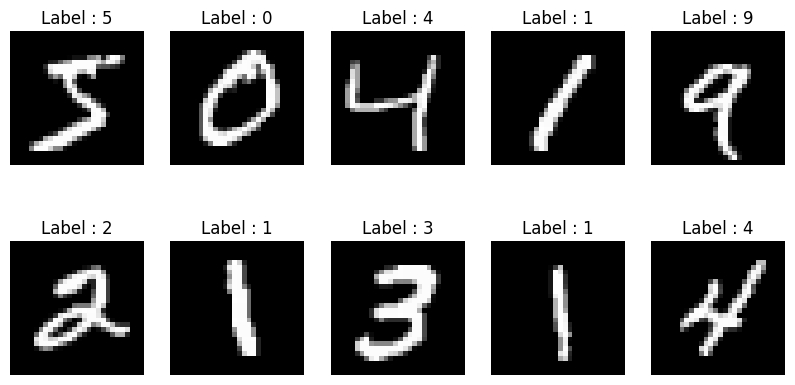

In [4]:
# Display Sample Images

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title("Label : {}".format(y_train[i]))
    plt.axis('off')

plt.show()


In [5]:
# Data Preprocessing

# Normalize pixel values (0-255 -> 0-1)

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


In [6]:
# One Hot Encoding

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("One Hot Label Example")
print(y_train_cat[0])


One Hot Label Example
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [7]:
# Building ANN Model

model = Sequential()

# Flatten Layer (28x28 -> 784)
model.add(Flatten(input_shape=(28,28)))
# Hidden Layer 1
model.add(Dense(128, activation='relu'))
# Hidden Layer 2
model.add(Dense(64, activation='relu'))
# Output Layer
model.add(Dense(10, activation='softmax'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:

# Compiling Model

optimizer = SGD(learning_rate=0.01)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [9]:
# Model Summary

model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Training Model

history = model.fit(X_train,y_train_cat,validation_split=0.2,epochs=20,batch_size=64,verbose=1)


Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7425 - loss: 1.0056 - val_accuracy: 0.8837 - val_loss: 0.4512
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8905 - loss: 0.4067 - val_accuracy: 0.9095 - val_loss: 0.3336
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9081 - loss: 0.3289 - val_accuracy: 0.9161 - val_loss: 0.2923
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9184 - loss: 0.2907 - val_accuracy: 0.9237 - val_loss: 0.2630
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9251 - loss: 0.2643 - val_accuracy: 0.9273 - val_loss: 0.2478
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9302 - loss: 0.2440 - val_accuracy: 0.9341 - val_loss: 0.2299
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9349 - loss: 0.2273 - val_accuracy: 0.9377 - val_loss: 0.2199
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9390 - loss: 0.2133 - val_accuracy: 0.

In [11]:
# Evaluating Model

loss, accuracy = model.evaluate(X_test, y_test_cat)

print("\nTest Loss :", loss)
print("Test Accuracy :", accuracy)



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9595 - loss: 0.1366

Test Loss : 0.13660012185573578
Test Accuracy : 0.9595000147819519


In [12]:
# Predicting on Test Images

predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)



313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


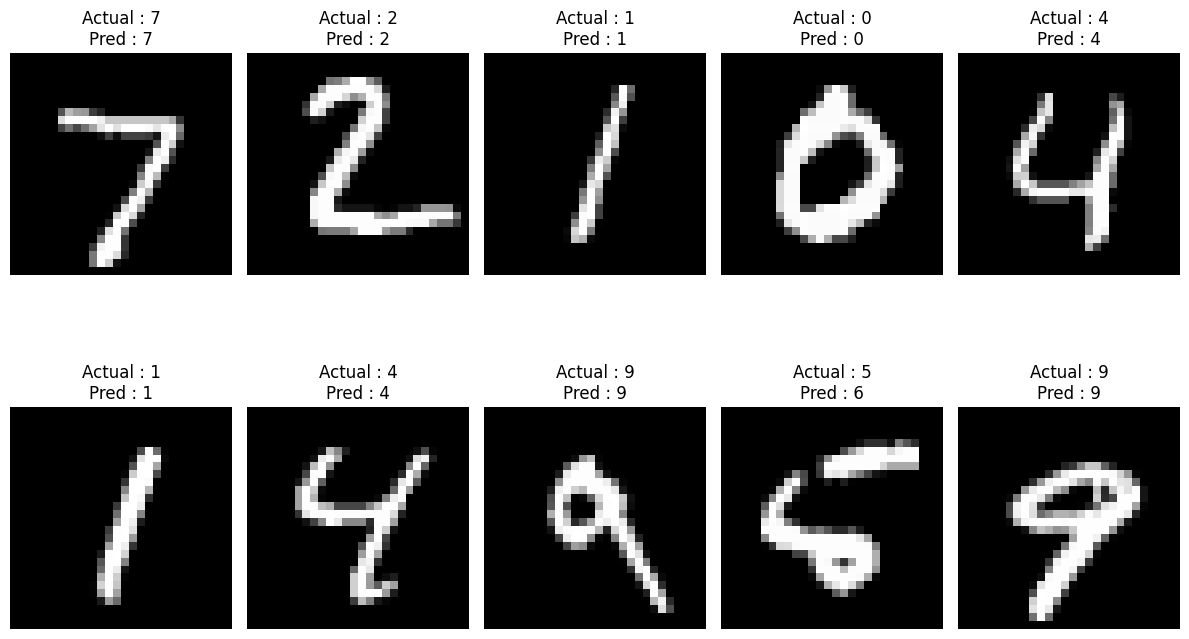

In [13]:

# Displaying Predictions

plt.figure(figsize=(12,8))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Actual : {y_test[i]}\nPred : {predicted_classes[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


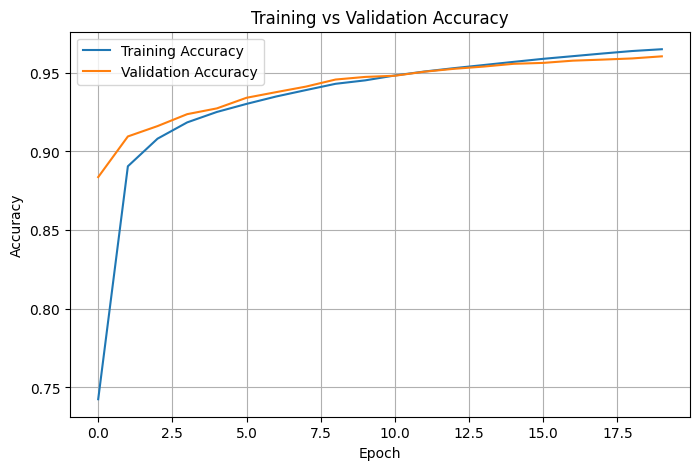

In [14]:
# Ploting Training Accuracy

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()



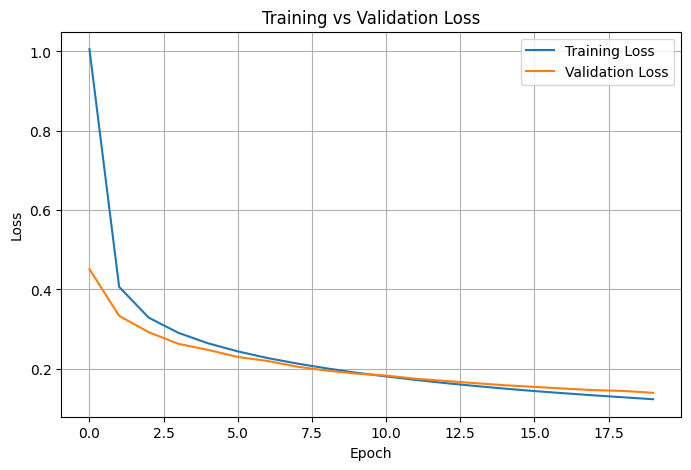

In [15]:

# Ploting Training Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


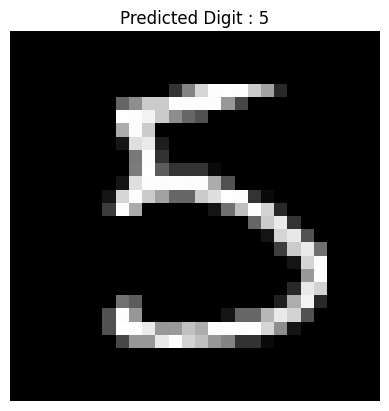

Prediction Probabilities
[[1.6346251e-04 1.8655147e-03 4.0129140e-05 3.0462680e-02 4.0157316e-05
  9.6221948e-01 2.6387022e-05 2.8759992e-05 4.9399436e-03 2.1340747e-04]]


In [16]:

# Predicting Single Image

index = 15
image = X_test[index]
prediction = model.predict(np.expand_dims(image, axis=0))
digit = np.argmax(prediction)
plt.imshow(image, cmap='gray')
plt.title(f"Predicted Digit : {digit}")
plt.axis('off')
plt.show()
print("Prediction Probabilities")
print(prediction)